Text(0, 0.5, 'Amplitude [dB]')

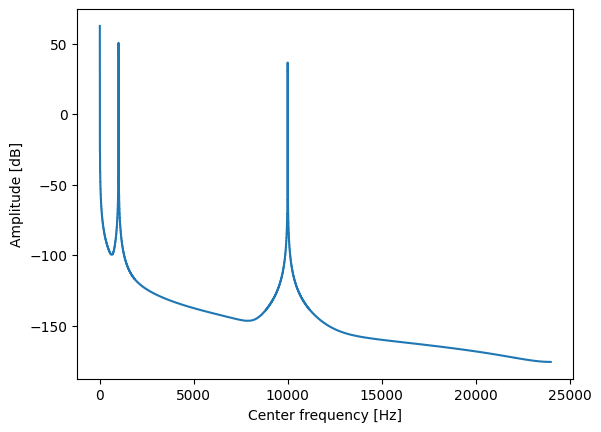

In [5]:
from mosqito.sound_level_meter import comp_spectrum
import matplotlib.pyplot as plt
import numpy as np


fs=48000
d=0.2
dB=60
time = np.arange(0, d, 1/fs)
f = 1000
stimulus = 1 + 0.5*np.sin(2 * np.pi * f * time) + 0.1*np.sin(20 * np.pi * f * time)
rms = np.sqrt(np.mean(np.power(stimulus, 2)))
ampl = 0.00002 * np.power(10, dB / 20) / rms
stimulus = stimulus * ampl


spec_db, freq_axis = comp_spectrum(stimulus, fs, db=True)
plt.step(freq_axis, spec_db)
plt.xlabel("Center frequency [Hz]")
plt.ylabel("Amplitude [dB]")

In [1]:
from mosqito.sq_metrics import (
    loudness_zwst,        # Loudness ISO 532-1, stationary
    sharpness_din_st,     # Sharpness DIN 45692, stationary
    roughness_dw,         # Roughness Daniel & Weber 1997
    sii_ansi,             # Speech Intelligibility Index ANSI S3.5
)


import numpy as np

Text(0, 0.5, 'Loudness [Sone]')

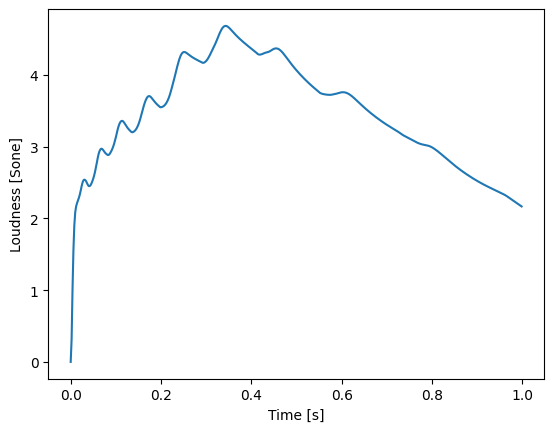

In [2]:
from mosqito.sq_metrics import loudness_zwtv
import matplotlib.pyplot as plt
import numpy as np
fs=48000
d=1
dB=60
time = np.arange(0, d, 1/fs)
f = np.linspace(1000,5000, len(time))
stimulus = 0.5 * (1 + np.sin(2 * np.pi * f * time))
rms = np.sqrt(np.mean(np.power(stimulus, 2)))
ampl = 0.00002 * np.power(10, dB / 20) / rms
stimulus = stimulus * ampl
N, N_spec, bark_axis, time_axis = loudness_zwtv(stimulus, fs)
plt.plot(time_axis, N)
plt.xlabel("Time [s]")
plt.ylabel("Loudness [Sone]")

In [5]:
import numpy as np
from scipy.io import wavfile

def generate_pink_noise(n_samples, sample_rate):
    # Generate white noise
    white_noise = np.random.randn(n_samples)
    
    # Compute FFT of white noise
    white_fft = np.fft.rfft(white_noise)
    
    # Compute frequency bins
    freqs = np.fft.rfftfreq(n_samples, d=1/sample_rate)
    
    # Compute scaling factors for each frequency bin to create pink noise
    scale = np.zeros_like(freqs)
    scale[1:] = 1 / np.sqrt(freqs[1:])  # Exclude DC component
    
    # Apply scaling to FFT of white noise
    pink_fft = white_fft * scale
    
    # Inverse FFT to obtain pink noise
    pink_noise = np.fft.irfft(pink_fft)
    
    # Normalize to 16-bit range
    pink_noise *= 32767 / np.max(np.abs(pink_noise))
    
    return pink_noise.astype(np.int16)

# Generate pink noise
sample_rate = 48000
duration = 10  # seconds
n_samples = sample_rate * duration

pink = generate_pink_noise(n_samples, sample_rate)

# Save pink noise to WAV file
wavfile.write('pink_noise.wav', sample_rate, pink)

print("Pink noise generated and saved to 'pink_noise.wav'.")

Pink noise generated and saved to 'pink_noise.wav'.


In [4]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

""" 
This script reads in a wav file, runs an FFT against it, 
and then stores the magnitude plot as a .png image
"""

def analyze_wav_file(file_name):
    sample_rate, data = wavfile.read(file_name)

    # Perform the FFT
    fft_result = np.fft.fft(data)

    # Get real and imaginary parts
    real_part = np.real(fft_result)
    imag_part = np.imag(fft_result)

    # Calculate magnitude
    magnitude = np.sqrt(real_part**2 + imag_part**2)

    # Convert magnitude to dB (To plot a log)
    magnitude_db = 20 * np.log10(magnitude)

    # Create frequency axis
    freq = np.fft.fftfreq(len(magnitude), 1/sample_rate)

    # Only keep positive frequencies
    positive_freq_mask = freq >= 0
    freq = freq[positive_freq_mask]
    magnitude_db = magnitude_db[positive_freq_mask]

    # Plot the magnitude in dB
    plt.figure(figsize=(12, 6))
    plt.plot(freq, magnitude_db)
    plt.title(f'FFT Magnitude (dB) for {file_name}')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Magnitude [dB]')
    plt.savefig(f'magnitude_{file_name}.png')  # Save the figure as 'magnitude.png'
    plt.close()  # Close the figure to free up memory

# Read the .wav file
file_name = 'pink_noise.wav'
analyze_wav_file(file_name)

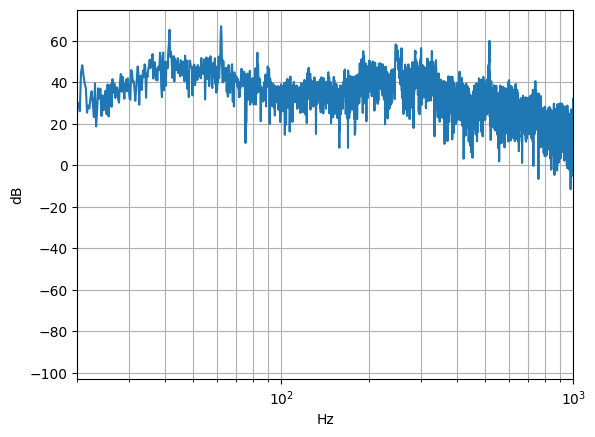

In [1]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

x, fs = sf.read("data/reference/refrigerator.wav")
X = np.abs(np.fft.rfft(x))
f = np.fft.rfftfreq(len(x), d=1/fs)

plt.semilogx(f, 20*np.log10(X + 1e-12))
plt.xlim(20, 1000)
plt.xlabel("Hz"); plt.ylabel("dB")
plt.grid(True, which='both')
plt.show()

In [2]:
import numpy as np
import soundfile as sf

x, fs = sf.read("data/reference/refrigerator.wav")
X = np.abs(np.fft.rfft(x))
f = np.fft.rfftfreq(len(x), d=1/fs)

# Top 10 picos entre 30 y 500 Hz
mask = (f >= 30) & (f <= 500)
top = np.argsort(X[mask])[::-1][:10]
for i in top:
    print(f"  {f[mask][i]:6.1f} Hz : {20*np.log10(X[mask][i]+1e-12):.1f} dB")

    62.2 Hz : 67.1 dB
    41.4 Hz : 65.5 dB
    62.0 Hz : 63.8 dB
    62.4 Hz : 61.8 dB
    41.2 Hz : 58.9 dB
   246.6 Hz : 58.4 dB
   246.4 Hz : 58.3 dB
   247.8 Hz : 57.9 dB
   246.8 Hz : 57.7 dB
   246.0 Hz : 56.9 dB
